# Linear regression in diabetes dataset

Let's explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)).

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [9]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

Let's explore this variable by looking at the different attributes (keys) of `diabetes`. Note that the `load_diabetes` function does not return dataframes. It returns you a Python dictionary.

In [10]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

#### The next step is to read the description of the dataset. 

Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable. Read the data description carefully to fully understand what each column represents.

*Hint: If your output is ill-formatted by displaying linebreaks as `\n`, it means you are not using the `print` function.*

In [11]:
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

#### Based on the data description, answer the following questions:

1. How many attributes are there in the data? What do they mean?

1. What is the relation between `diabetes['data']` and `diabetes['target']`?

1. How many records are there in the data?

In [12]:
#1. Hay 10 atributos numéricos (edad, sexo, indice de masa corporal, presion sanguínea
# y 6 valores diferentes de medición de parámetros sanguíneos) 

#2.  data contiene todos los parámtros del paciente y target y es una medición cualitativa del estado
# del paciente un año después

#3.  442

#### Now explore what are contained in the *data* portion as well as the *target* portion of `diabetes`. 

Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). Inspect the shape of `data` and `target`. Confirm they are consistent with the data description.

In [13]:
diabetes ['data']

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [14]:
diabetes['target']

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

## Building a regression model

The data have already been split to predictor (*data*) and response (*target*) variables. Given this information, we'll apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset.

#### In the cell below, import the `linear_model` class from `sklearn`. 

In [15]:
from sklearn.linear_model import LinearRegression

#### Create a new instance of the linear regression model and assign the new instance to the variable `diabetes_model`.

In [16]:
diabetes_model = LinearRegression()


#### Next, let's split the training and test data.

Define `diabetes_data_train`, `diabetes_target_train`, `diabetes_data_test`, and `diabetes_target_test`. Use the last 20 records for the test data and the rest for the training data.

In [17]:
diabetes_data_train = diabetes ['data'][:421]
diabetes_target_train = diabetes ['target'][:421]
diabetes_data_test = diabetes ['data'][422:]
diabetes_target_test = diabetes ['target'][422:]

Perform a brief exploratory analysis to investigate the conditions necessary for linear regression. This analysis will help you understand the distribution of the target variable and its correlations with other features.

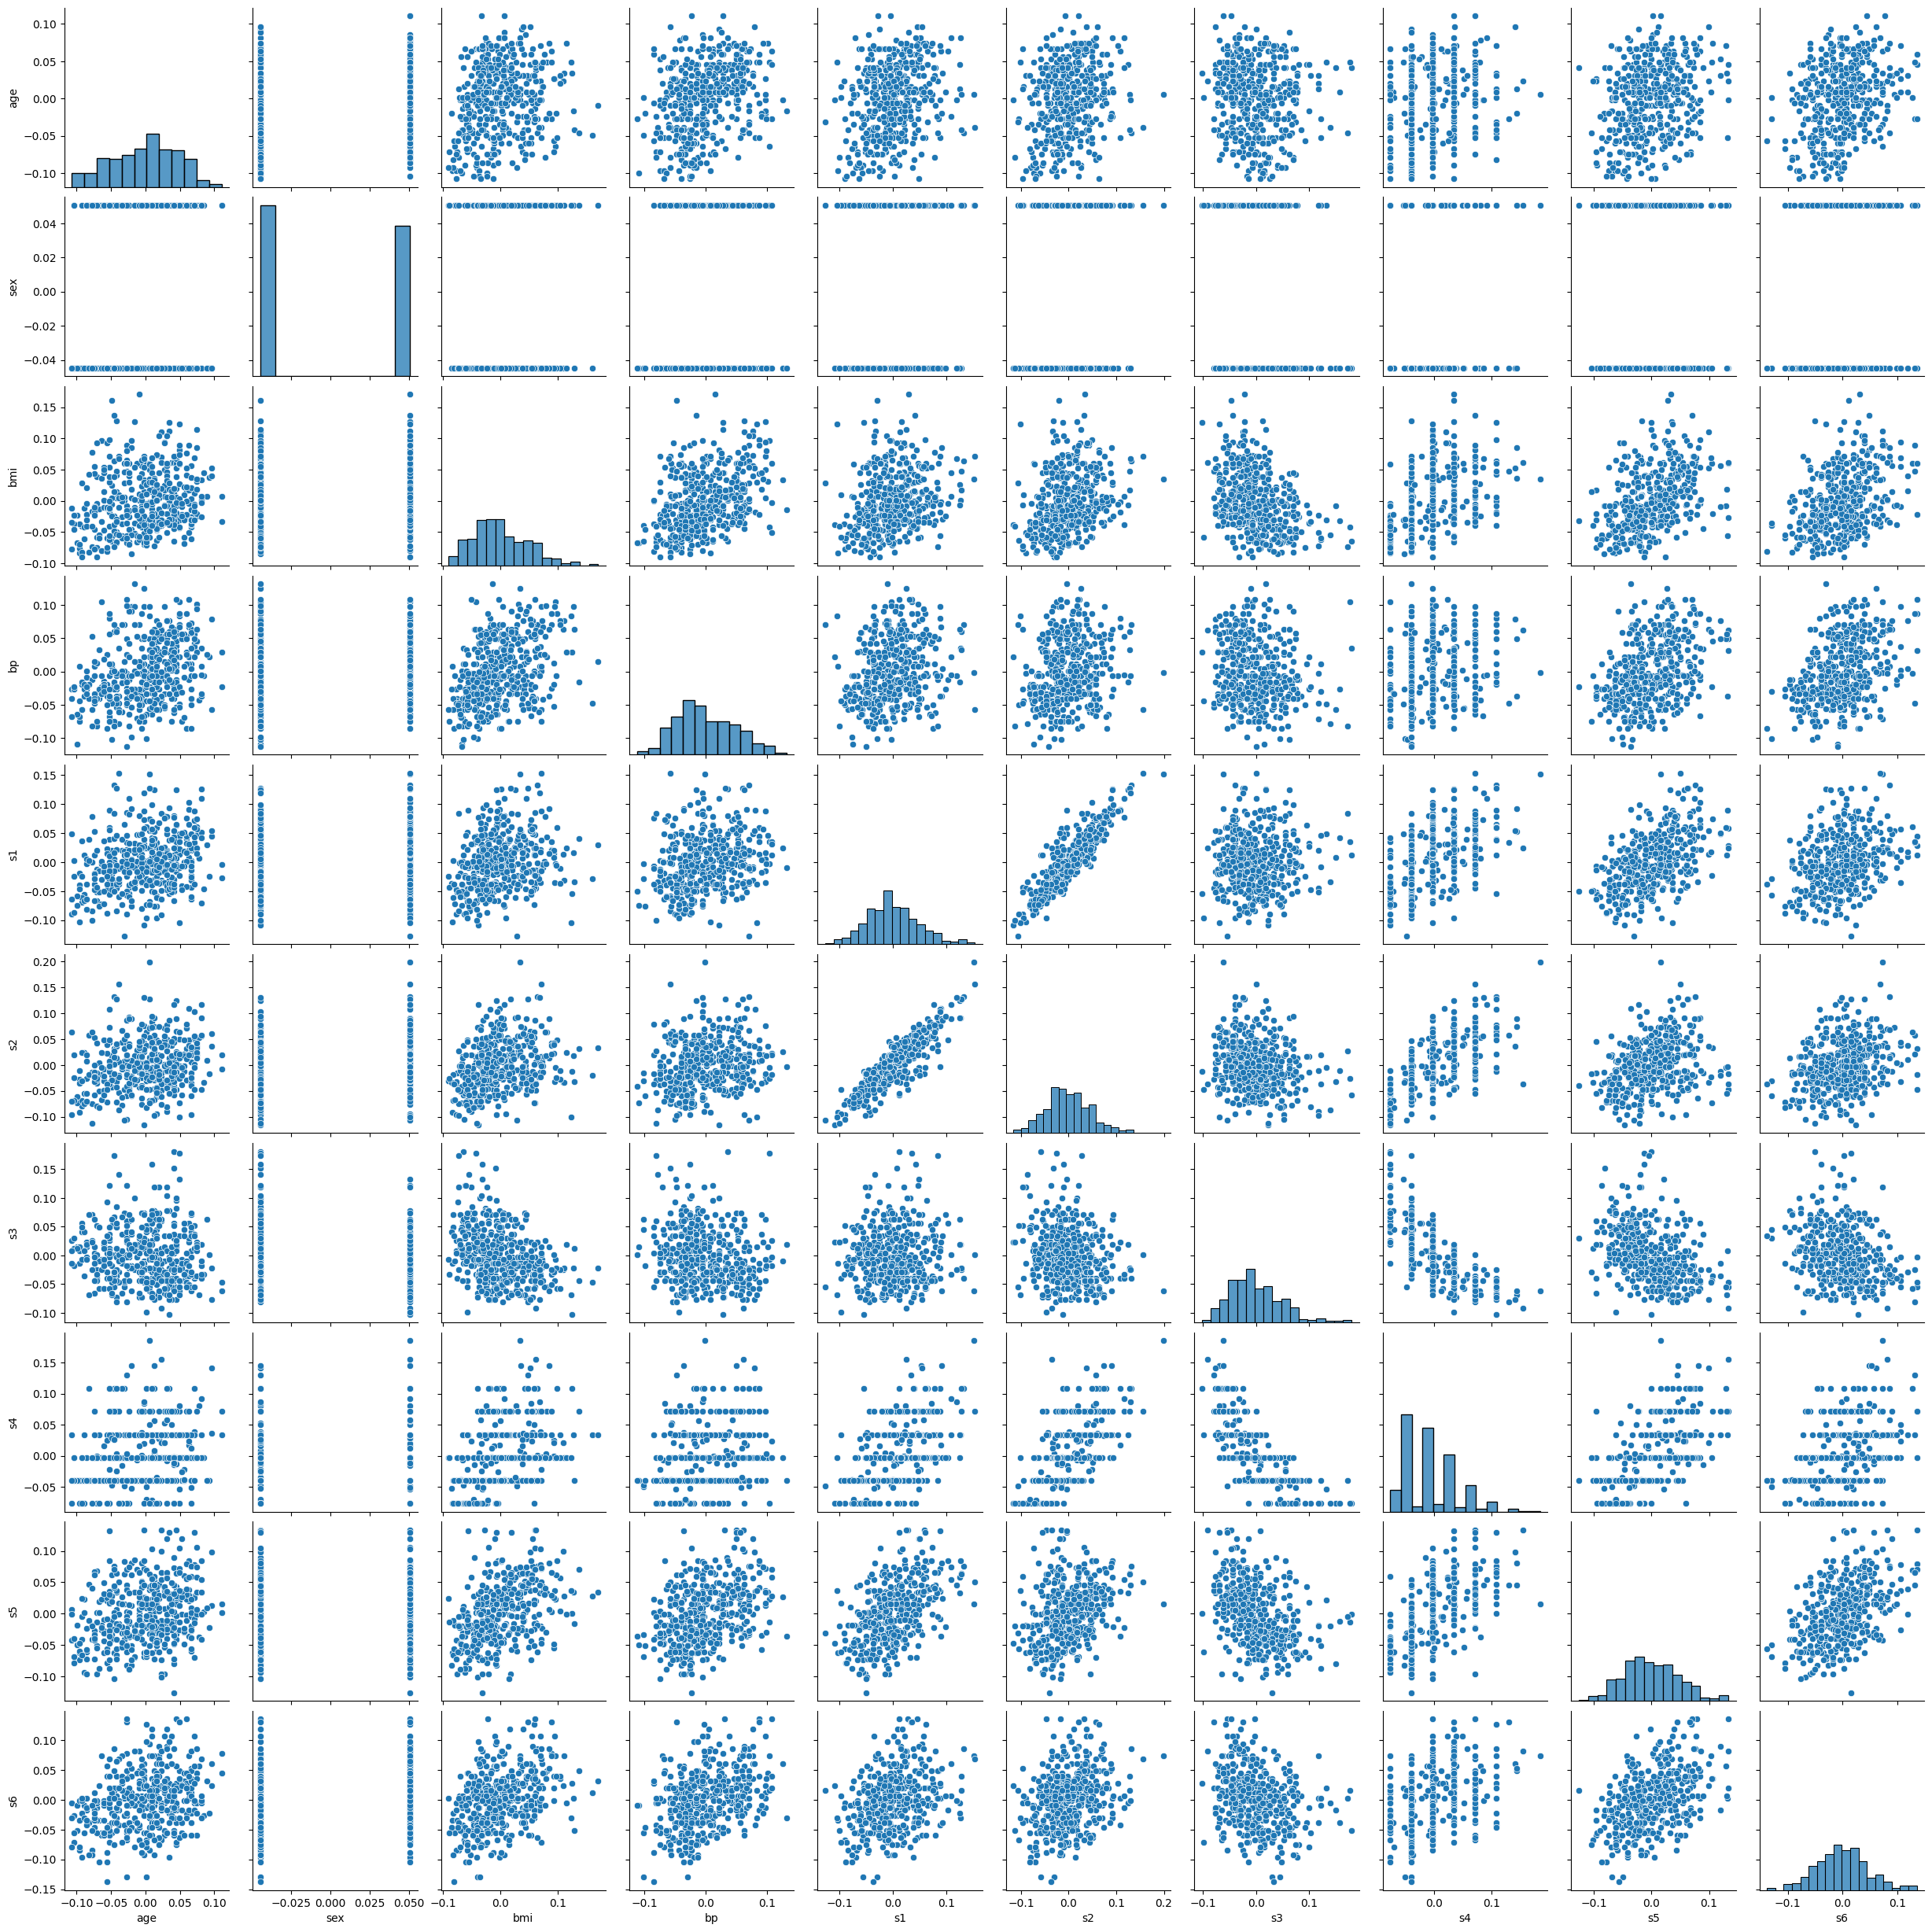

In [ ]:
# Aquí me falta el target!!!
df_diabetes = pd.DataFrame (diabetes['data'], columns=diabetes['feature_names'])
sns.pairplot (pd.DataFrame(df_diabetes))

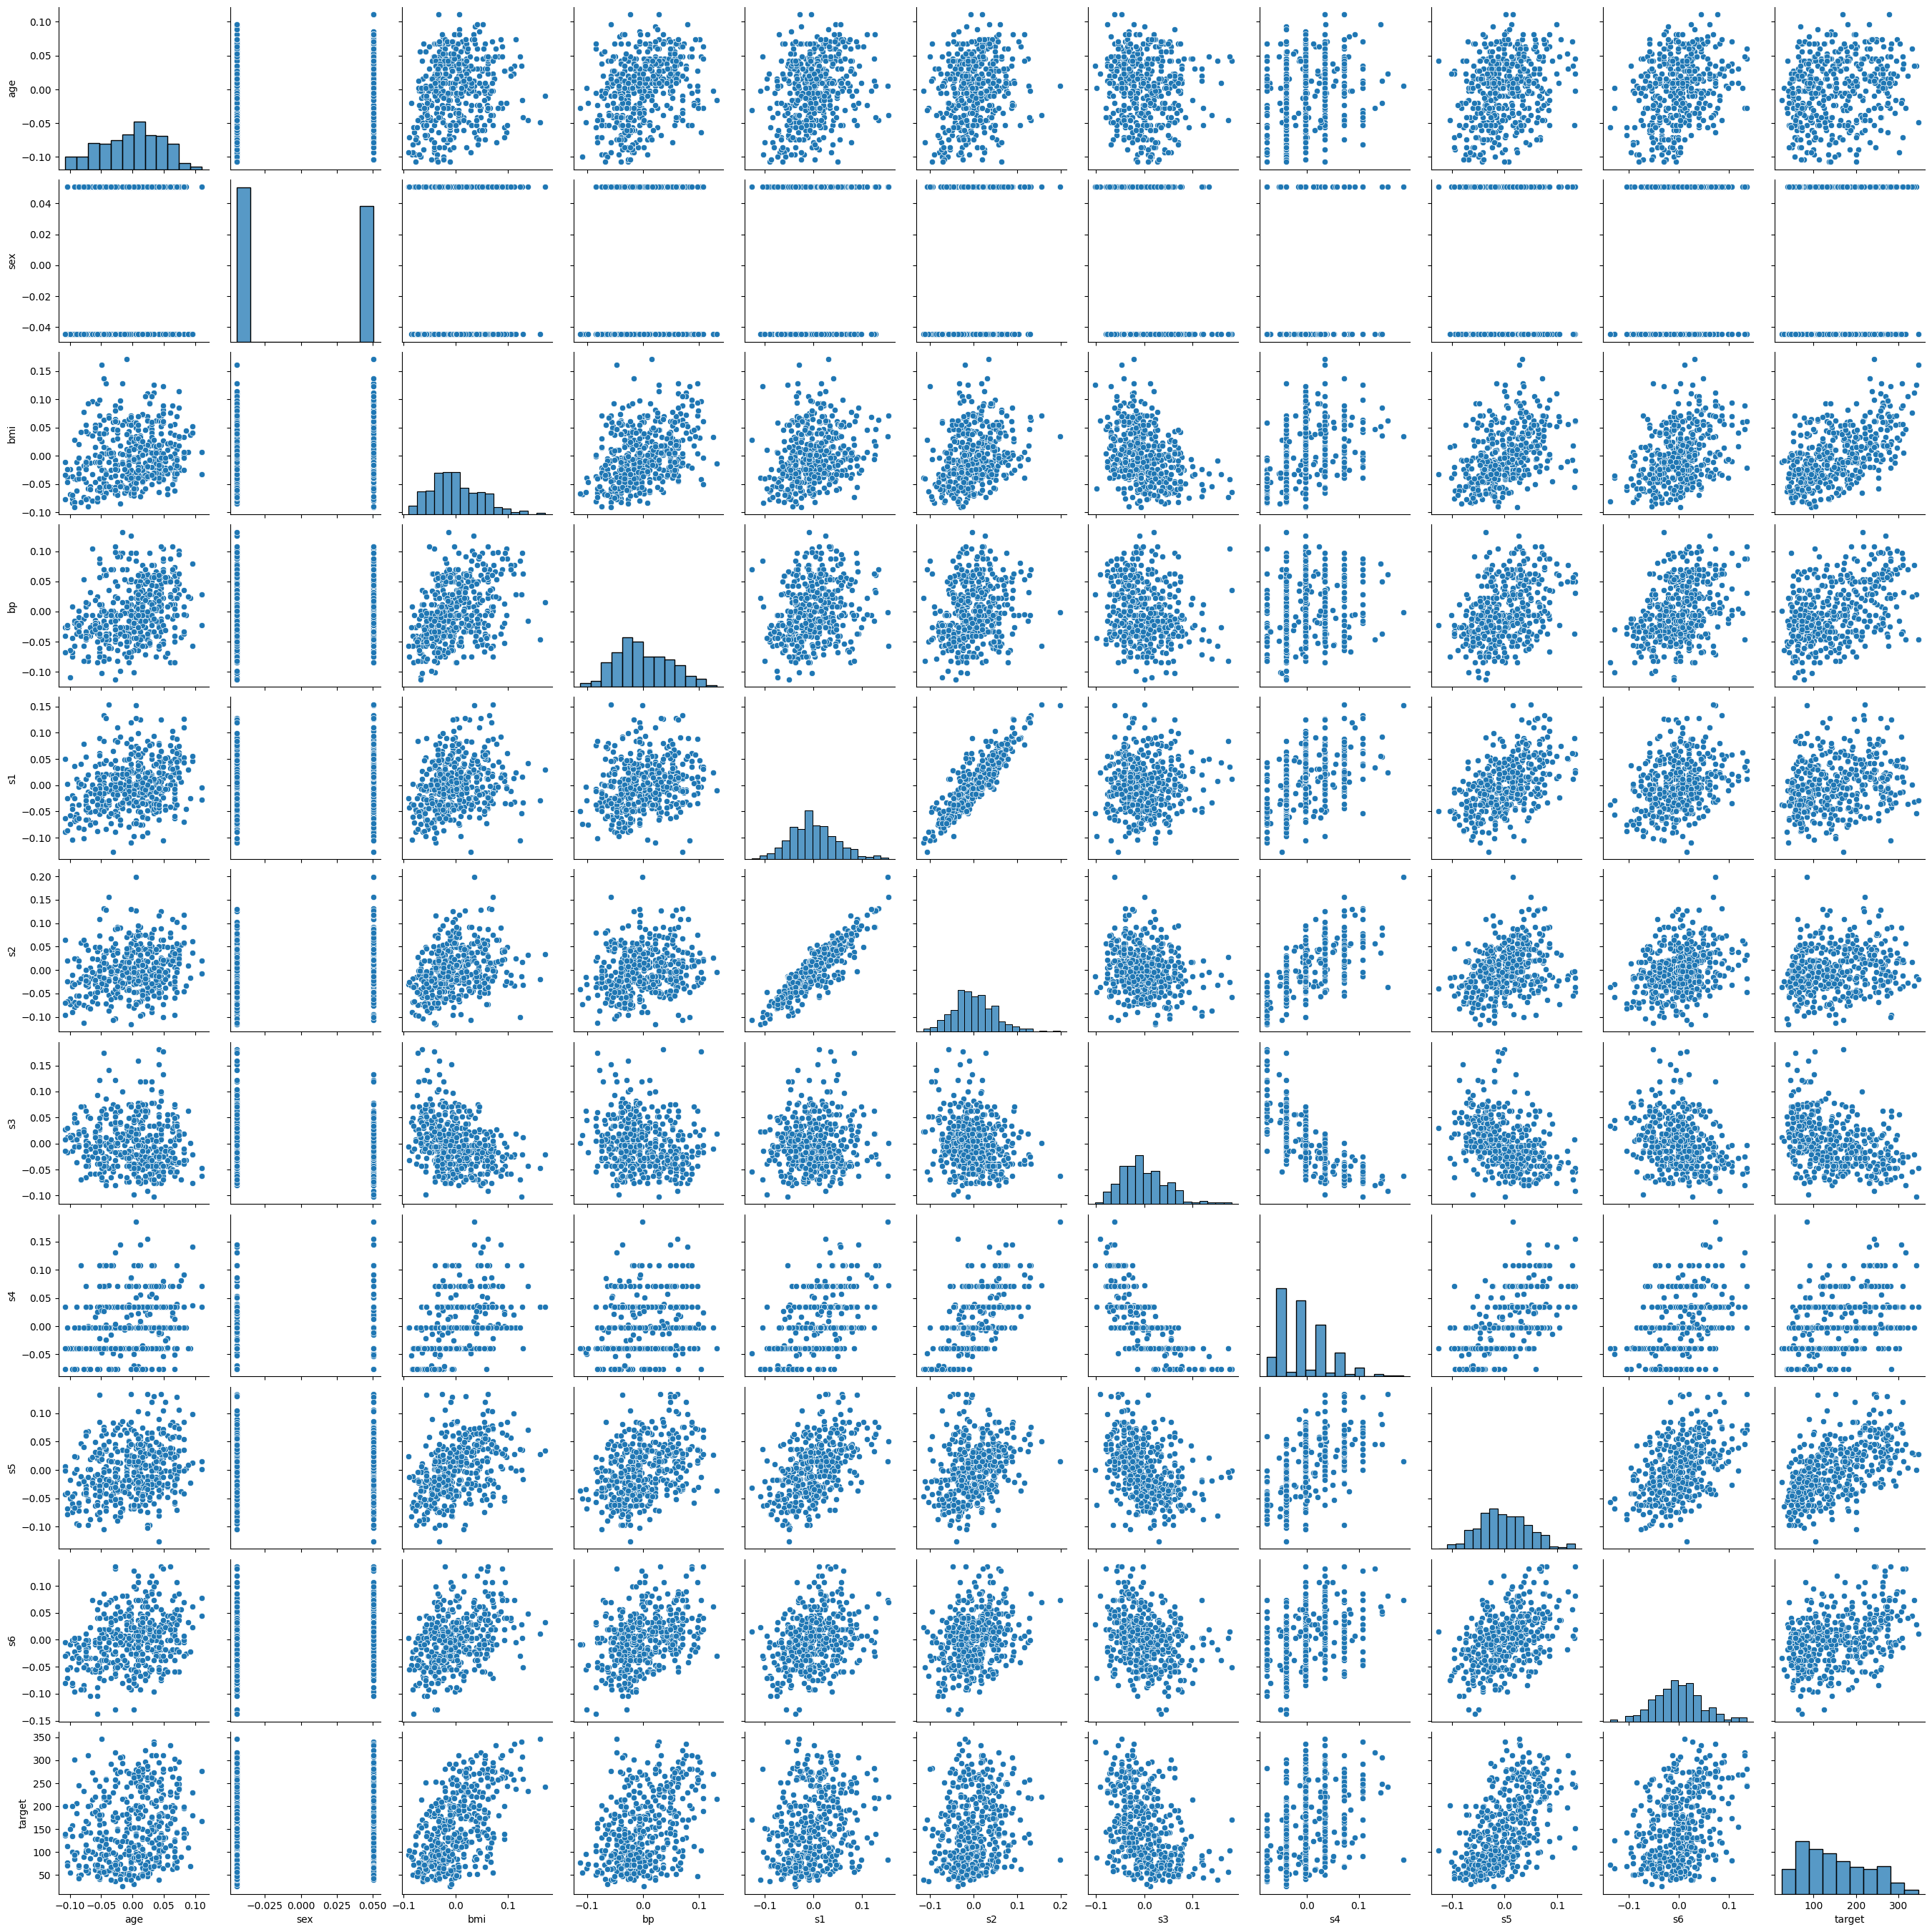

In [ ]:
df_diabetes = pd.DataFrame (diabetes['data'], columns=diabetes['feature_names'])
#Meter el target!! Si no no veo cómo interactúa con él
df_diabetes ['target'] = diabetes ['target']
sns.pairplot (pd.DataFrame(df_diabetes))

In [ ]:
# qué parámetros correlacionan con el target. bmi, 
# s1 y s2 correlacionan mucho entre sí
# s3 y s4 también correlacionan entre sí
# El target no tiene una distribución normal. No es lo ideal para este modelo (pero como por ahora
# no tenemos otro...)

In [31]:
df_diabetes.describe()

,age,sex,bmi,bp,s1,s2,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [ ]:
#se ve que edad, sexo y bmi se han escalado (lo sabemos por conocimiento de negocio). Igual los otros
# también pero sin tener conocimiento no lo sabemos.

<Axes: >

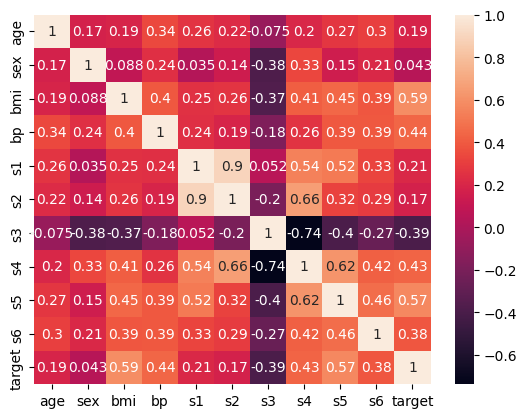

In [36]:
sns.heatmap(df_diabetes.corr(), annot=True)

Fit the training data and target to `diabetes_model`. Print the *intercept* and *coefficients* of the model.

In [20]:
diabetes_model.fit (diabetes_data_train, diabetes_target_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
print (diabetes_model.intercept_)
print (diabetes_model.coef_)

152.71891711421404
[-1.79148110e-01 -2.38288634e+02  5.10810037e+02  3.27719349e+02
 -8.09853252e+02  4.89826090e+02  1.00210128e+02  1.81971925e+02
  7.41705037e+02  7.66608561e+01]


#### Inspecting the results

From the outputs you should have seen:

- The intercept is a float number.
- The coefficients are an array containing 10 float numbers.

This is the linear regression model fitted to your training dataset.

#### Using your fitted linear regression model, predict the *y* of `diabetes_data_test`.

In [22]:
predictions = diabetes_model.predict(diabetes_data_test)

#### Print your `diabetes_target_test` and compare with the prediction. 

<Axes: >

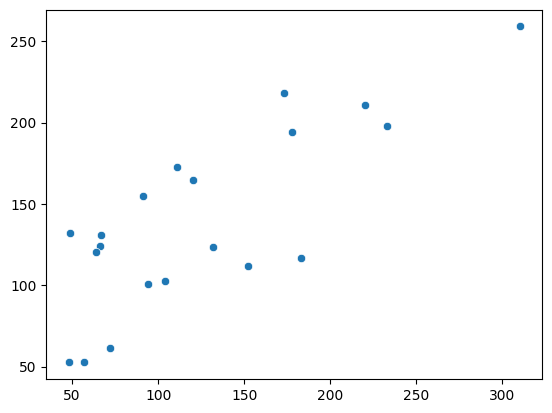

In [ ]:
# Si fuese perfecto sería una línea recta. En este caso hay dispersión
sns.scatterplot(x=diabetes_target_test,y=predictions)

#### Is `diabetes_target_test` exactly the same as the model prediction? Use different error metrics

In [24]:
from sklearn import metrics
import numpy as np

print('MAE:', metrics.mean_absolute_error(diabetes_target_test, predictions))
print('MSE:', metrics.mean_squared_error(diabetes_target_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(diabetes_target_test, predictions)))
print('MAPE:', metrics.mean_absolute_percentage_error(diabetes_target_test, predictions))

MAE: 36.599232263413526
MSE: 2002.2636009434973
RMSE: 44.746660221110325
MAPE: 0.39305211377327287


In [ ]:
#MAPE 39%! es bastante malo

#### Iterate with a new model to assess if any improvements can be made compared to the previous one. Consider reducing the number of variables or using `StandardScaler` to enhance model performance.

In [25]:
#s3 y s4 están muy correlacionadas. Quito s3 que tiene un coeficiente menor
# es la columna 6
df_diabetes = df_diabetes.drop(columns=['s3'])


In [26]:
df_diabetes

,age,sex,bmi,bp,s1,s2,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,0.026560,0.044529,-0.025930


In [27]:
df_target = pd.DataFrame(diabetes['target'])

In [ ]:
diabetes_data_train = df_diabetes[:421]
diabetes_target_train = df_target [:421]
diabetes_data_test = df_diabetes[422:]
diabetes_target_test = df_target[422:]

# También puede hacerse con data_test_split. test_size, le paso un número y shuffle=False que sean las últimas
# diabetes_data_train, diabetes_data_test, diabetes_target_train, diabetes_target_test = 
# train_test_split(df.drop("target", axis="columns"), df['target'], test_size = 20, shuffle=False)

In [ ]:
#Escalar
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Escalamos el train. Esto es lo que me había dicho Claude. David hace diferente.
# No tengo nada claro qué estoy haciendo 
X_train_scaled = scaler.fit_transform(diabetes_data_train)
X_test_scaled = scaler.transform(diabetes_data_test)  # solo transform, no fit

# Lo que hace David: creo que es lo mismo. 
# 

# 
# scaler = StandardScaler()

#'entreno' el escaler, o sea saco los valores por los que los voy a escalar los datos, eso es fit.
# lo hago sólo con los datos de entrenamiento y luego aplico esa escala a los datos de train y de 
# test

# scaler.fit(X_train)
# X_train_scal = scaler.transform(X_train)
# X_test_scal = scaler.transform(X_test)

lm = LinearRegression()
lm.fit(X_train_scaled,diabetes_target_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
predictions = lm.predict(X_test_scaled)

In [52]:
print('MAE:', metrics.mean_absolute_error(diabetes_target_test, predictions))
print('MSE:', metrics.mean_squared_error(diabetes_target_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(diabetes_target_test, predictions)))
print('MAPE:', metrics.mean_absolute_percentage_error(diabetes_target_test, predictions))

MAE: 950.7661371285052
MSE: 1259654.064086513
RMSE: 1122.3431133510433
MAPE: 10.134975502263725


In [ ]:
#DAVID se queda con las variables que tienen más correlación con el target y además no meter cosas que 
# tengan colinealidad

# X = df[['bmi', 's1', 's5', 'sex','bp']]
# y = df['target']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

#Mejora algo (tampoco mucho) pero es más sencillo. Ver en Diabetes.ipynb